# Activation diagnostics for Legendre emulation

All three constructions evaluate the same probability-normalized root factorization
\(\psi_n(x)=a_n\prod_k(x-r_k)\) for the probability measure \(dx/2\).
ReLU multiplication is approximate and controlled by a depth parameter. Tanh
multiplication uses optimized finite differences, tight partial-product bounds,
and an automatically scaled product tree. RePU-2
multiplication uses an exact algebraic
identity, up to floating-point roundoff.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from neural_polynomial_emulation import (
    LegendreEmulator,
    basis_error_by_degree,
    emulated_legendre_basis,
    exact_legendre_basis,
    relative_frobenius_mismatch,
)

PRODUCTS = ("relu", "tanh", "repu2")
TANH_TOLERANCE = 1e-4


## Pointwise basis error


In [2]:
rows = []
for product in PRODUCTS:
    errors = basis_error_by_degree(
        16,
        product=product,
        num_layers=12,
        tanh_step=None,
        tanh_tolerance=TANH_TOLERANCE,
        grid_size=2001,
    )
    rows.extend(
        {"degree": degree, "product": product, "sup_error": error}
        for degree, error in enumerate(errors)
    )
error_table = pd.DataFrame(rows)
error_table.pivot(index="degree", columns="product", values="sup_error")


product,relu,repu2,tanh
degree,,,
0,0.000000e+00,0.000000e+00,0.000000e+00
1,0.000000e+00,0.000000e+00,0.000000e+00
2,9.362618e-07,1.332268e-15,2.083048e-06
3,1.276717e-05,3.996803e-15,5.994677e-06
4,1.068409e-04,1.199041e-14,1.856466e-06
5,8.336835e-04,2.620126e-14,2.295992e-06
6,6.251628e-03,5.440093e-14,3.684726e-06
7,4.807105e-02,1.287859e-13,3.313735e-06
8,3.939169e-01,3.347322e-13,1.308648e-06


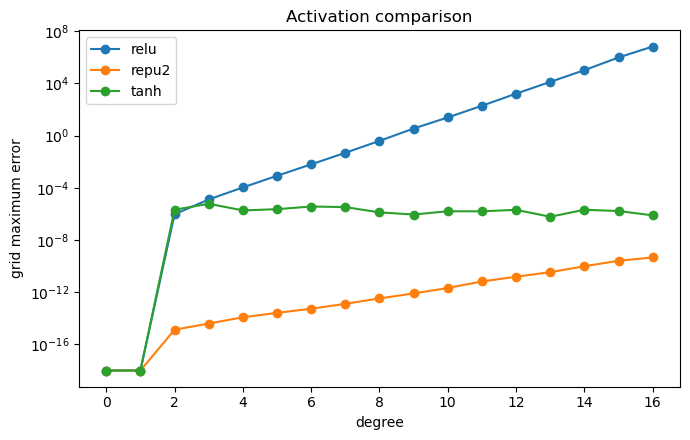

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for product, group in error_table.groupby("product"):
    ax.semilogy(group["degree"], np.maximum(group["sup_error"], 1e-18), marker="o", label=product)
ax.set(xlabel="degree", ylabel="grid maximum error", title="Activation comparison")
ax.legend()
fig.tight_layout()
plt.show()


## Measurement-matrix mismatch


In [4]:
rng = np.random.default_rng(90210)
samples = rng.uniform(-1.0, 1.0, size=512)
rows = []
for max_degree in (4, 8, 12, 16, 24):
    exact = exact_legendre_basis(samples, max_degree)
    for product in PRODUCTS:
        approximate = emulated_legendre_basis(
            samples,
            max_degree,
            product=product,
            num_layers=12,
            tanh_step=None,
            tanh_tolerance=TANH_TOLERANCE,
        ).numpy()
        rows.append({
            "max_degree": max_degree,
            "product": product,
            "relative_frobenius_mismatch": relative_frobenius_mismatch(exact, approximate),
        })
matrix_table = pd.DataFrame(rows)
matrix_table.pivot(index="max_degree", columns="product", values="relative_frobenius_mismatch")


product,relu,repu2,tanh
max_degree,,,
4,1.944380e-05,1.471183e-15,5.748235e-07
8,6.363846e-02,1.703894e-14,4.768410e-07
12,2.238103e+02,5.689216e-13,4.016001e-07
16,6.127481e+05,1.651273e-11,3.526435e-07
24,1.134912e+13,1.797107e-08,2.913010e-07


## Tanh step-size sensitivity

The explicit-step sweep exposes the truncation/cancellation tradeoff. The
package default instead allocates the requested tolerance over the product
tree and chooses a dtype-aware step at each node.


degree,8,16,24
step,,,
0.001,4.386578e-08,1.278068e-07,6.307951e-07
0.002,1.081631e-08,3.743395e-08,1.264459e-07
0.005,1.565487e-09,6.303541e-09,1.185516e-08
0.010,5.570357e-09,2.002635e-08,3.186763e-08
0.020,9.006867e-08,2.777786e-07,5.368829e-07
0.050,3.520962e-06,1.084687e-05,2.103182e-05
0.100,5.629973e-05,1.734314e-04,3.362602e-04
0.200,8.983724e-04,2.766587e-03,5.362275e-03
0.400,1.418719e-02,4.354888e-02,8.409507e-02


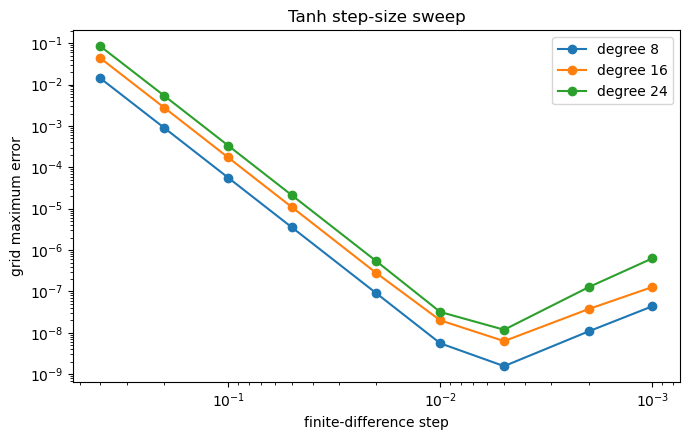

{8: ((0.0294015850406182,
   0.0329733052470935,
   0.024339248615745053,
   0.031694055254752544),
  (0.03477492023267557, 0.044153608720645186),
  (0.05069152584342976,)),
 16: ((0.01637158218740146,
   0.01739819412650879,
   0.017680168770082185,
   0.02026696342313996,
   0.015928897242614048,
   0.019775726732887723,
   0.013259945936712514,
   0.017927619571921127),
  (0.022854926736411003,
   0.025955706426624862,
   0.018802550076981457,
   0.02495683383918661),
  (0.02679617420086117, 0.03412858227679257),
  (0.03876729563891554,)),
 24: ((0.01162097742778505,
   0.012112722947207135,
   0.015293516187115825,
   0.01677939586220329,
   0.012102902871153424,
   0.013996247402494437,
   0.011257734317539327,
   0.013745944595919077,
   0.01323885690118092,
   0.01710585343949172,
   0.009303344885076215,
   0.012757033713595028),
  (0.016180564659231553,
   0.017655887453696024,
   0.018843533599065907,
   0.022784307113857396,
   0.01317281380023842,
   0.017818883159562447),


In [5]:
sweep_rows = []
for degree in (8, 16, 24):
    for step in (0.4, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001):
        error = basis_error_by_degree(
            degree, product="tanh", tanh_step=step, grid_size=2001
        )[degree]
        sweep_rows.append({"degree": degree, "step": step, "sup_error": error})
sweep_table = pd.DataFrame(sweep_rows)
display(sweep_table.pivot(index="step", columns="degree", values="sup_error"))

fig, ax = plt.subplots(figsize=(7, 4.5))
for degree, group in sweep_table.groupby("degree"):
    ax.loglog(group["step"], group["sup_error"], marker="o", label=f"degree {degree}")
ax.invert_xaxis()
ax.set(xlabel="finite-difference step", ylabel="grid maximum error", title="Tanh step-size sweep")
ax.legend()
fig.tight_layout()
plt.show()

automatic_steps = {
    degree: LegendreEmulator(
        degree, product="tanh", tanh_tolerance=TANH_TOLERANCE
    ).tanh_steps(torch.float64)
    for degree in (8, 16, 24)
}
automatic_steps


RePU-2 isolates the conditioning of sequential root multiplication because its
binary products are algebraically exact. The ReLU curve additionally contains
the accumulated approximation error of its squaring networks. The tanh curve
contains finite-difference multiplication error and uses a bound-aware product
tree, so it also reflects a different error-propagation architecture.
